In [15]:

import os
import pandas as pd
import numpy as np

from nixtla import NixtlaClient
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import plotly.graph_objects as go
from utilsforecast.preprocessing import fill_gaps
import vectorbt as vbt
import ta



In [16]:

%run ../../base/set_secrets.ipynb
%run ../../base/plot.ipynb
%run ../../prepare_data/prepare_data.ipynb


In [17]:

api_key = os.getenv('NIXTLA_API_KEY')
if not api_key:
    raise ValueError("NIXTLA_API_KEY not found in environment variables. Please set it.")

ticker = 'SBER'
rolling_step = 7   
forecast_horizon = 7  
rolling_period_days = 365 


df = pd.read_csv('../../data/'+ticker+'/1day.csv')


df.rename(columns={'time': 'ds', 'close': 'y'}, inplace=True)
df['ds'] = pd.to_datetime(df['ds'])
df['unique_id'] = ticker # Use ticker name as unique_id


In [18]:

duplicates = df[df.duplicated(subset=['ds'], keep=False)]
if not duplicates.empty:
    print(f"Found {len(duplicates)} duplicate timestamps. Dropping duplicates, keeping first.")
    df = df.drop_duplicates(subset=['ds'], keep='first')


Found 6 duplicate timestamps. Dropping duplicates, keeping first.


In [19]:
df = fill_gaps(df, freq='D', id_col='unique_id', time_col='ds')

df['y'] = df['y'].interpolate(method='linear', limit_direction='both')
df['high'] = df['high'].interpolate(method='linear', limit_direction='both')
df['low'] = df['low'].interpolate(method='linear', limit_direction='both')
df['open'] = df['open'].interpolate(method='linear', limit_direction='both')
df['volume'] = df['volume'].interpolate(method='linear', limit_direction='both')
df['unique_id'] = 'SBER'

df = df[ ['ds', 'y', 'high', 'low', 'open', 'volume', 'unique_id'] ]
df

,ds,y,high,low,open,volume,unique_id
0,2018-01-01 00:00:00+00:00,225.20,226.20,223.27,224.12,1891986.0,SBER
1,2018-01-02 00:00:00+00:00,225.20,226.20,223.27,224.12,1891986.0,SBER
2,2018-01-03 00:00:00+00:00,231.90,232.70,226.35,226.88,3454962.0,SBER
3,2018-01-04 00:00:00+00:00,238.80,239.50,231.00,232.13,5359852.0,SBER
4,2018-01-05 00:00:00+00:00,238.60,239.95,236.70,238.89,3157919.0,SBER
...,...,...,...,...,...,...,...
2647,2025-04-01 00:00:00+00:00,303.24,312.90,302.70,310.50,4608834.0,SBER
2648,2025-04-02 00:00:00+00:00,306.11,306.50,301.21,303.23,4020702.0,SBER
2649,2025-04-03 00:00:00+00:00,302.09,309.20,296.00,306.21,5240856.0,SBER
2650,2025-04-04 00:00:00+00:00,285.35,304.37,284.40,303.55,8871920.0,SBER


In [20]:

timegpt = NixtlaClient(api_key=api_key)

end_date = df['ds'].max()
start_date_rolling_forecast = end_date - pd.Timedelta(days=rolling_period_days)

test_comparison_df = df[df['ds'] > start_date_rolling_forecast].copy()

all_forecasts_list = []
current_forecast_start_date = start_date_rolling_forecast

iteration = 0
max_iterations = (rolling_period_days // rolling_step) + 1 

while current_forecast_start_date <= end_date:
	iteration += 1
	print(f"\nIteration {iteration}/{max_iterations}...")

	train_end_date = current_forecast_start_date - pd.Timedelta(days=1)
	current_train_df = df[df['ds'] <= train_end_date].copy()

	print(f"  Training data ends: {train_end_date.date()} ({len(current_train_df)} points)")
	print(f"  Forecasting for {forecast_horizon} days starting from: {current_forecast_start_date.date()}")

	forecast_step_df = timegpt.forecast(
		df=current_train_df[['unique_id', 'ds', 'y', 'high', 'low', 'volume', 'open']], 
		h=forecast_horizon,
		level=[80, 95],
		finetune_steps=10, 
		finetune_loss='mae',
		freq='D', 
		target_col='y',
		hist_exog_list=['high', 'low', 'volume', 'open'],
		#model='timegpt-1-long-horizon',
	)
	all_forecasts_list.append(forecast_step_df)
	print(f"Received {len(forecast_step_df)} predicted points.")

	current_forecast_start_date += pd.Timedelta(days=rolling_step)


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Querying model metadata...



Iteration 1/53...
  Training data ends: 2024-04-04 (2286 points)
  Forecasting for 7 days starting from: 2024-04-05


INFO:nixtla.nixtla_client:Using historical exogenous features: ['high', 'low', 'volume', 'open']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...
INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using historical exogenous features: ['high', 'low', 'volume', 'open']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Received 7 predicted points.

Iteration 2/53...
  Training data ends: 2024-04-11 (2293 points)
  Forecasting for 7 days starting from: 2024-04-12


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using historical exogenous features: ['high', 'low', 'volume', 'open']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


...

Received 7 predicted points.

Iteration 51/53...
  Training data ends: 2025-03-20 (2636 points)
  Forecasting for 7 days starting from: 2025-03-21


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using historical exogenous features: ['high', 'low', 'volume', 'open']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Received 7 predicted points.

Iteration 52/53...
  Training data ends: 2025-03-27 (2643 points)
  Forecasting for 7 days starting from: 2025-03-28


INFO:nixtla.nixtla_client:Validating inputs...
INFO:nixtla.nixtla_client:Preprocessing dataframes...
INFO:nixtla.nixtla_client:Using historical exogenous features: ['high', 'low', 'volume', 'open']
INFO:nixtla.nixtla_client:Calling Forecast Endpoint...


Received 7 predicted points.

Iteration 53/53...
  Training data ends: 2025-04-03 (2650 points)
  Forecasting for 7 days starting from: 2025-04-04
Received 7 predicted points.


In [21]:

combined_forecast_df = pd.concat(all_forecasts_list)

combined_forecast_df = combined_forecast_df.sort_values(by=['unique_id', 'ds'])
forecast_df = combined_forecast_df.drop_duplicates(subset=['unique_id', 'ds'], keep='first').reset_index(drop=True)

print(forecast_df.head())


  unique_id                        ds    TimeGPT  TimeGPT-hi-80  \
0      SBER 2024-04-05 00:00:00+00:00  304.62363      309.76712   
1      SBER 2024-04-06 00:00:00+00:00  304.51580      310.43073   
2      SBER 2024-04-07 00:00:00+00:00  304.36066      311.20312   
3      SBER 2024-04-08 00:00:00+00:00  304.32470      312.32495   
4      SBER 2024-04-09 00:00:00+00:00  304.35596      312.92642   

   TimeGPT-hi-95  TimeGPT-lo-80  TimeGPT-lo-95  
0      314.62817      299.48013      294.61908  
1      315.82385      298.60090      293.20776  
2      319.15546      297.51820      289.56586  
3      322.07724      296.32446      286.57217  
4      321.41525      295.78550      287.29666  


In [22]:

fig_forecast = go.Figure()

historical_plot_df = df[df['ds'] <= forecast_df['ds'].min()] # Show data before the first forecast point
#historical_plot_df = historical_plot_df.tail(200)
fig_forecast.add_trace(go.Scatter(
    x=historical_plot_df['ds'],
    y=historical_plot_df['y'],
    mode='lines',
    name='Исторические данные',
    line=dict(color='blue')
))

# Actual data during the forecast period (for comparison)
actuals_plot_df = df[df['ds'] >= forecast_df['ds'].min()]
fig_forecast.add_trace(go.Scatter(
    x=actuals_plot_df['ds'],
    y=actuals_plot_df['y'],
    mode='lines',
    name='Фактические данные (Test Period)',
    line=dict(color='rgba(230,20,20,0.8)')#, dash='dash') 
))

# Combined TimeGPT Forecast
fig_forecast.add_trace(go.Scatter(
    x=forecast_df['ds'],
    y=forecast_df['TimeGPT'],
    mode='lines',
    name='Прогноз TimeGPT (Rolling)',
    line=dict(color='green')
))

# Confidence Intervals (if generated and consistent across runs)
if 'TimeGPT-hi-95' in forecast_df.columns and 'TimeGPT-lo-95' in forecast_df.columns:
    fig_forecast.add_trace(go.Scatter(
        x=forecast_df['ds'],
        y=forecast_df['TimeGPT-hi-95'],
        mode='lines',
        line=dict(width=0),
        showlegend=False
    ))
    fig_forecast.add_trace(go.Scatter(
        x=forecast_df['ds'],
        y=forecast_df['TimeGPT-lo-95'],
        mode='lines',
        line=dict(width=0),
        fillcolor='rgba(0,100,80,0.2)',
        fill='tonexty',
        name='95% Доверительный интервал'
    ))

if 'TimeGPT-hi-80' in forecast_df.columns and 'TimeGPT-lo-80' in forecast_df.columns:
    fig_forecast.add_trace(go.Scatter(
        x=forecast_df['ds'],
        y=forecast_df['TimeGPT-hi-80'],
        mode='lines',
        line=dict(width=0),
        showlegend=False
    ))
    fig_forecast.add_trace(go.Scatter(
        x=forecast_df['ds'],
        y=forecast_df['TimeGPT-lo-80'],
        mode='lines',
        line=dict(width=0),
        fillcolor='rgba(0,176,246,0.2)',
        fill='tonexty',
        name='80% Доверительный интервал'
    ))

fig_forecast.update_layout(
    title=f'Rolling TimeGPT Forecast для {ticker} (Step={rolling_step}d, Horizon={forecast_horizon}d)',
    xaxis_title='Дата',
    yaxis_title='Цена (y)',
    legend_title='Данные'
)
fig_forecast.show()


In [23]:
comparison_df = pd.merge(
    test_comparison_df[['ds', 'y']], 
    forecast_df[['ds', 'TimeGPT']],  
    on='ds',
    how='inner' 
)


y_true = comparison_df['y']
y_pred = comparison_df['TimeGPT']

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred) * 100

print("\nМетрики качества:")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")




Метрики качества:
MAE: 5.1782
MSE: 60.8059
RMSE: 7.7978
MAPE: 1.88%


<Axes: ylabel='features'>

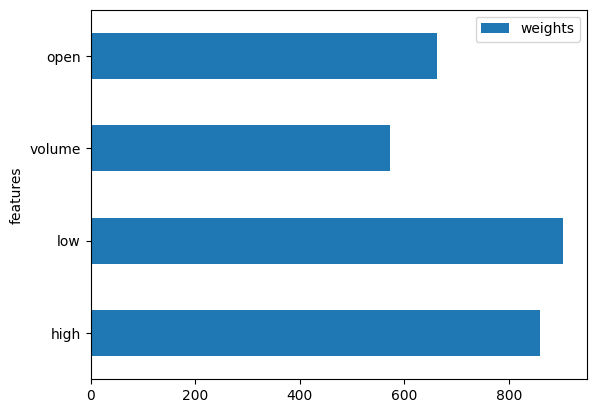

In [ ]:
timegpt.weights_x.plot.barh(x='features', y='weights')